In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Preprocess the data
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# Convert labels to one-hot encoding
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test = keras.utils.to_categorical(y_test, num_classes=10)

# Define the neural network model
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax"),
])

# Compile the model
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Display model summary
model.summary()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [2]:
# You can now train the model by uncommenting the following line:
model.fit(x_train, y_train, batch_size=128, epochs=10, validation_split=0.1)



Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.7624 - loss: 0.7776 - val_accuracy: 0.9778 - val_loss: 0.0830
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 89ms/step - accuracy: 0.9648 - loss: 0.1199 - val_accuracy: 0.9838 - val_loss: 0.0583
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 89ms/step - accuracy: 0.9732 - loss: 0.0870 - val_accuracy: 0.9880 - val_loss: 0.0485
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.9775 - loss: 0.0726 - val_accuracy: 0.9875 - val_loss: 0.0454
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 93ms/step - accuracy: 0.9802 - loss: 0.0619 - val_accuracy: 0.9898 - val_loss: 0.0411
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 88ms/step - accuracy: 0.9825 - loss: 0.0559 - val_accuracy: 0.9895 - val_loss: 0.0376
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.9847 - loss: 0.0512 - val_accuracy: 0.9895 - val_loss: 0.0369
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.9848 - loss: 0.0477 - 

In [5]:
# And evaluate it with:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9883 - loss: 0.0333


[0.02840632013976574, 0.9902999997138977]

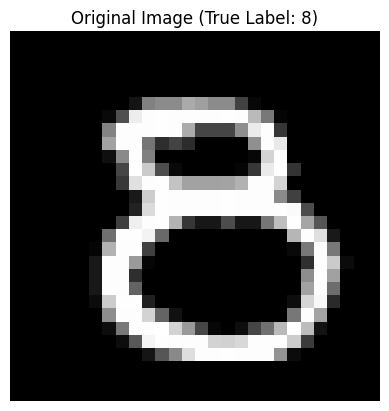

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Model Predicted: 8
Prediction probabilities: [4.8636903e-05 2.2913607e-13 3.2801606e-04 1.7025843e-05 2.6072024e-12
 1.2581469e-05 1.7087565e-08 1.5713708e-10 9.9958950e-01 4.1676535e-06]


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Select a random image from the test set
image_index = np.random.randint(0, len(x_test))
single_image = x_test[image_index]
single_label = np.argmax(y_test[image_index]) # Get the true label

# Display the original image
plt.imshow(single_image.reshape(28, 28), cmap='gray')
plt.title(f"Original Image (True Label: {single_label})")
plt.axis('off')
plt.show()

# Reshape the image for model prediction (add batch dimension)
image_for_prediction = np.expand_dims(single_image, axis=0)

# Get the model's prediction
predictions = model.predict(image_for_prediction)
predicted_class = np.argmax(predictions[0])

print(f"\nModel Predicted: {predicted_class}")
print(f"Prediction probabilities: {predictions[0]}")